# M01. Park and Weather Factors

### Imports

In [1]:
from DataImports import *

Batted Ball Angle Note:
- if y > 198.27 and x < 125.42), it's actually to left
- if y > 198.27 and x > 125.42), it's actually to right

### Settings

In [2]:
# Train Model A (batted ball)
train_batted_ball_model = False # Shouldn't need to be run often
# Count of Model B classifiers
ensemble_size = 5
# Save event averages (for use in WFX calculates)
save_event_averages = False

### Data

##### MLB Stats API

In [3]:
start_year, end_year = 2015, 2025

Merge MLB Stats API and Statcast data

In [4]:
%%time
df = merge_datasets(start_year, end_year)
df = clean_weather(df)
df = create_events(df)
df = create_variables(df)
df = start_data(df)

CPU times: total: 1min 35s
Wall time: 37.3 s


##### Open Meteo

Read in Open Meteo weather data

In [5]:
open_meteo_column_list = ['game_id', 'year', 'venue_name', 'location.defaultCoordinates.latitude', 'location.defaultCoordinates.longitude', 
                          'fieldInfo.leftLine', 'fieldInfo.center', 'fieldInfo.rightLine', 'fieldInfo.leftCenter', 'fieldInfo.rightCenter', 
                          'location.elevation', 'location.azimuthAngle', 'fieldInfo.roofType', 'active', 
                          'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure', 
                          'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'precipitation_probability']

In [6]:
weather_df = pd.concat(map(pd.read_csv, glob.glob(os.path.join(baseball_path, "A06. Weather", "1. Open Meteo", "*.csv"))), ignore_index=True)[open_meteo_column_list]

##### Baserunning

In [7]:
steamer_column_list = ['proj_date', 'mlbamid', 'PA', 'UBR']

In [8]:
steamer_hitters_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "steamer_hitters_weekly_log.csv"), encoding='iso-8859-1', usecols=steamer_column_list, dtype='str')

### Clean

##### MLB Stats API

Format data types for merge

In [9]:
df['proj_date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [10]:
df['mlbamid'] = df['batter'].astype(str)

##### Open Meteo

Calculate wind vectors

In [11]:
def calculate_vectors(row, azimuth_column, wind_column, speed_column):
    angle = row[wind_column] - row[azimuth_column]
    
    # Calculate vectors
    x_vect = round(math.sin(math.radians(angle)), 5) * row[speed_column] * -1
    y_vect = round(math.cos(math.radians(angle)), 5) * row[speed_column] * -1

    return pd.Series([x_vect, y_vect], index=['x_vect', 'y_vect'])

In [12]:
weather_df[['meteo_x_vect', 'meteo_y_vect']] = weather_df.apply(lambda row: calculate_vectors(row, 'location.azimuthAngle', 'wind_direction_10m', 'wind_speed_10m'), axis=1)

##### Base Running

Convert data types

In [13]:
steamer_hitters_df[['PA', 'UBR']] = steamer_hitters_df[['PA', 'UBR']].astype(float)

In [14]:
steamer_hitters_df['proj_date'] = pd.to_datetime(steamer_hitters_df['proj_date'])

Calculate UBR per 600 Plate Appearances

In [15]:
steamer_hitters_df['UBR600'] = steamer_hitters_df['UBR'] / steamer_hitters_df['PA'] * 600

### Merge

##### MLB Stats API with Open Meteo

In [16]:
df = df.merge(weather_df.drop(columns=['year']), left_on=['gamePk'], right_on=['game_id'], how='inner')

##### With Baserunning

In [17]:
df = pd.merge_asof(
    df.sort_values('proj_date'),
    steamer_hitters_df.sort_values('proj_date'),
    by='mlbamid',
    on='proj_date',
    direction='backward'
)

### Clean 2

Use weather column from MLB data to adjust for domes/roofs

In [18]:
mask = df['weather'].str.contains('Roof|Dome', case=False, na=False)

In [19]:
df.loc[mask, 'temperature'] = 70
df.loc[mask, 'x_vect'] = 0
df.loc[mask, 'y_vect'] = 0

In [20]:
df.loc[mask, 'temperature_2m'] = 70
df.loc[mask, 'meteo_x_vect'] = 0
df.loc[mask, 'meteo_y_vect'] = 0
df.loc[mask, 'relative_humidity_2m'] = 60
df.loc[mask, 'dew_point_2m'] = 57

### Model A. Batted Ball

Probability of events given how the baseball was launched, where it was launched to, and some information about the batter, including handedness and base running. Notably excluded park and weather.

$ \hat{\text{eventsModel}} = launch\_angle + launch\_speed + to\_l + to\_lc + to\_c + to\_rc + to\_r + b\_L + UBR600 $

##### Inputs

In [21]:
batted_ball_inputs = ['launch_angle', 'launch_speed', 'to_l', 'to_lc', 'to_c', 'to_rc', 'to_r', 'b_L', 'UBR600'] + ['bb', 'hbp', 'so']

##### Sample

Sent launch data to 0 if not batted

In [22]:
df[['launch_angle', 'launch_speed']] = df[['launch_angle', 'launch_speed']].fillna(0)

Remove atypical events and missings

In [23]:
df = df[~df['eventsModel'].isin(["Cut"])].dropna(subset=batted_ball_inputs)

Drop recent data (recent Steamer data is not available)

In [24]:
# df = df[df['date'] < 20250101]

Define model input and outputs

In [25]:
X = df[batted_ball_inputs].values
y = df[['eventsModel']].values

##### Encode

In [26]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # One-hot eventsModel
    encode_outcome = OneHotEncoder(sparse_output=False)
    # Fit and transform
    y_encoded = encode_outcome.fit_transform(y)
    # Create folder
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)   
    # Save
    pickle.dump(encode_outcome, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "encode_outcome.pkl"), 'wb'))
else:
    y_encoded = encode_outcome.transform(y)

##### Scale

In [27]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # Scale model inputs
    scale_inputs = StandardScaler()
    # Fit and transform
    X_scaled = scale_inputs.fit_transform(X)
    # Save
    pickle.dump(scale_inputs, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "scale_inputs.pkl"), 'wb'))
else:
    X_scaled = scale_inputs.transform(X)

##### Train

In [28]:
if not hasattr(sys.modules['__main__'], '__file__') and train_batted_ball_model == True:
    # Create neural network
    predict_outcome = Sequential([
        Dense(32, input_shape=(X_scaled.shape[1],), activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(y_encoded.shape[1], activation='softmax')])
    # Compile
    predict_outcome.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    # Add early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True)
    # Fit
    predict_outcome.fit(
        X_scaled, y_encoded,
        epochs=50,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stop])
    # Save
    predict_outcome.save(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, 'predict_outcome.keras'))

##### Predict

Predicted rates of events based on batted-ball data

In [29]:
predictions = predict_outcome.predict(X_scaled)

prediction_df = pd.DataFrame(predictions, columns=encode_outcome.categories_[0])
prediction_df = prediction_df.add_suffix('_pred_batted')

prediction_df = pd.concat([df.reset_index(drop=True), prediction_df], axis=1)

58143/58143 ━━━━━━━━━━━━━━━━━━━━ 26s 453us/step


##### Evaluate

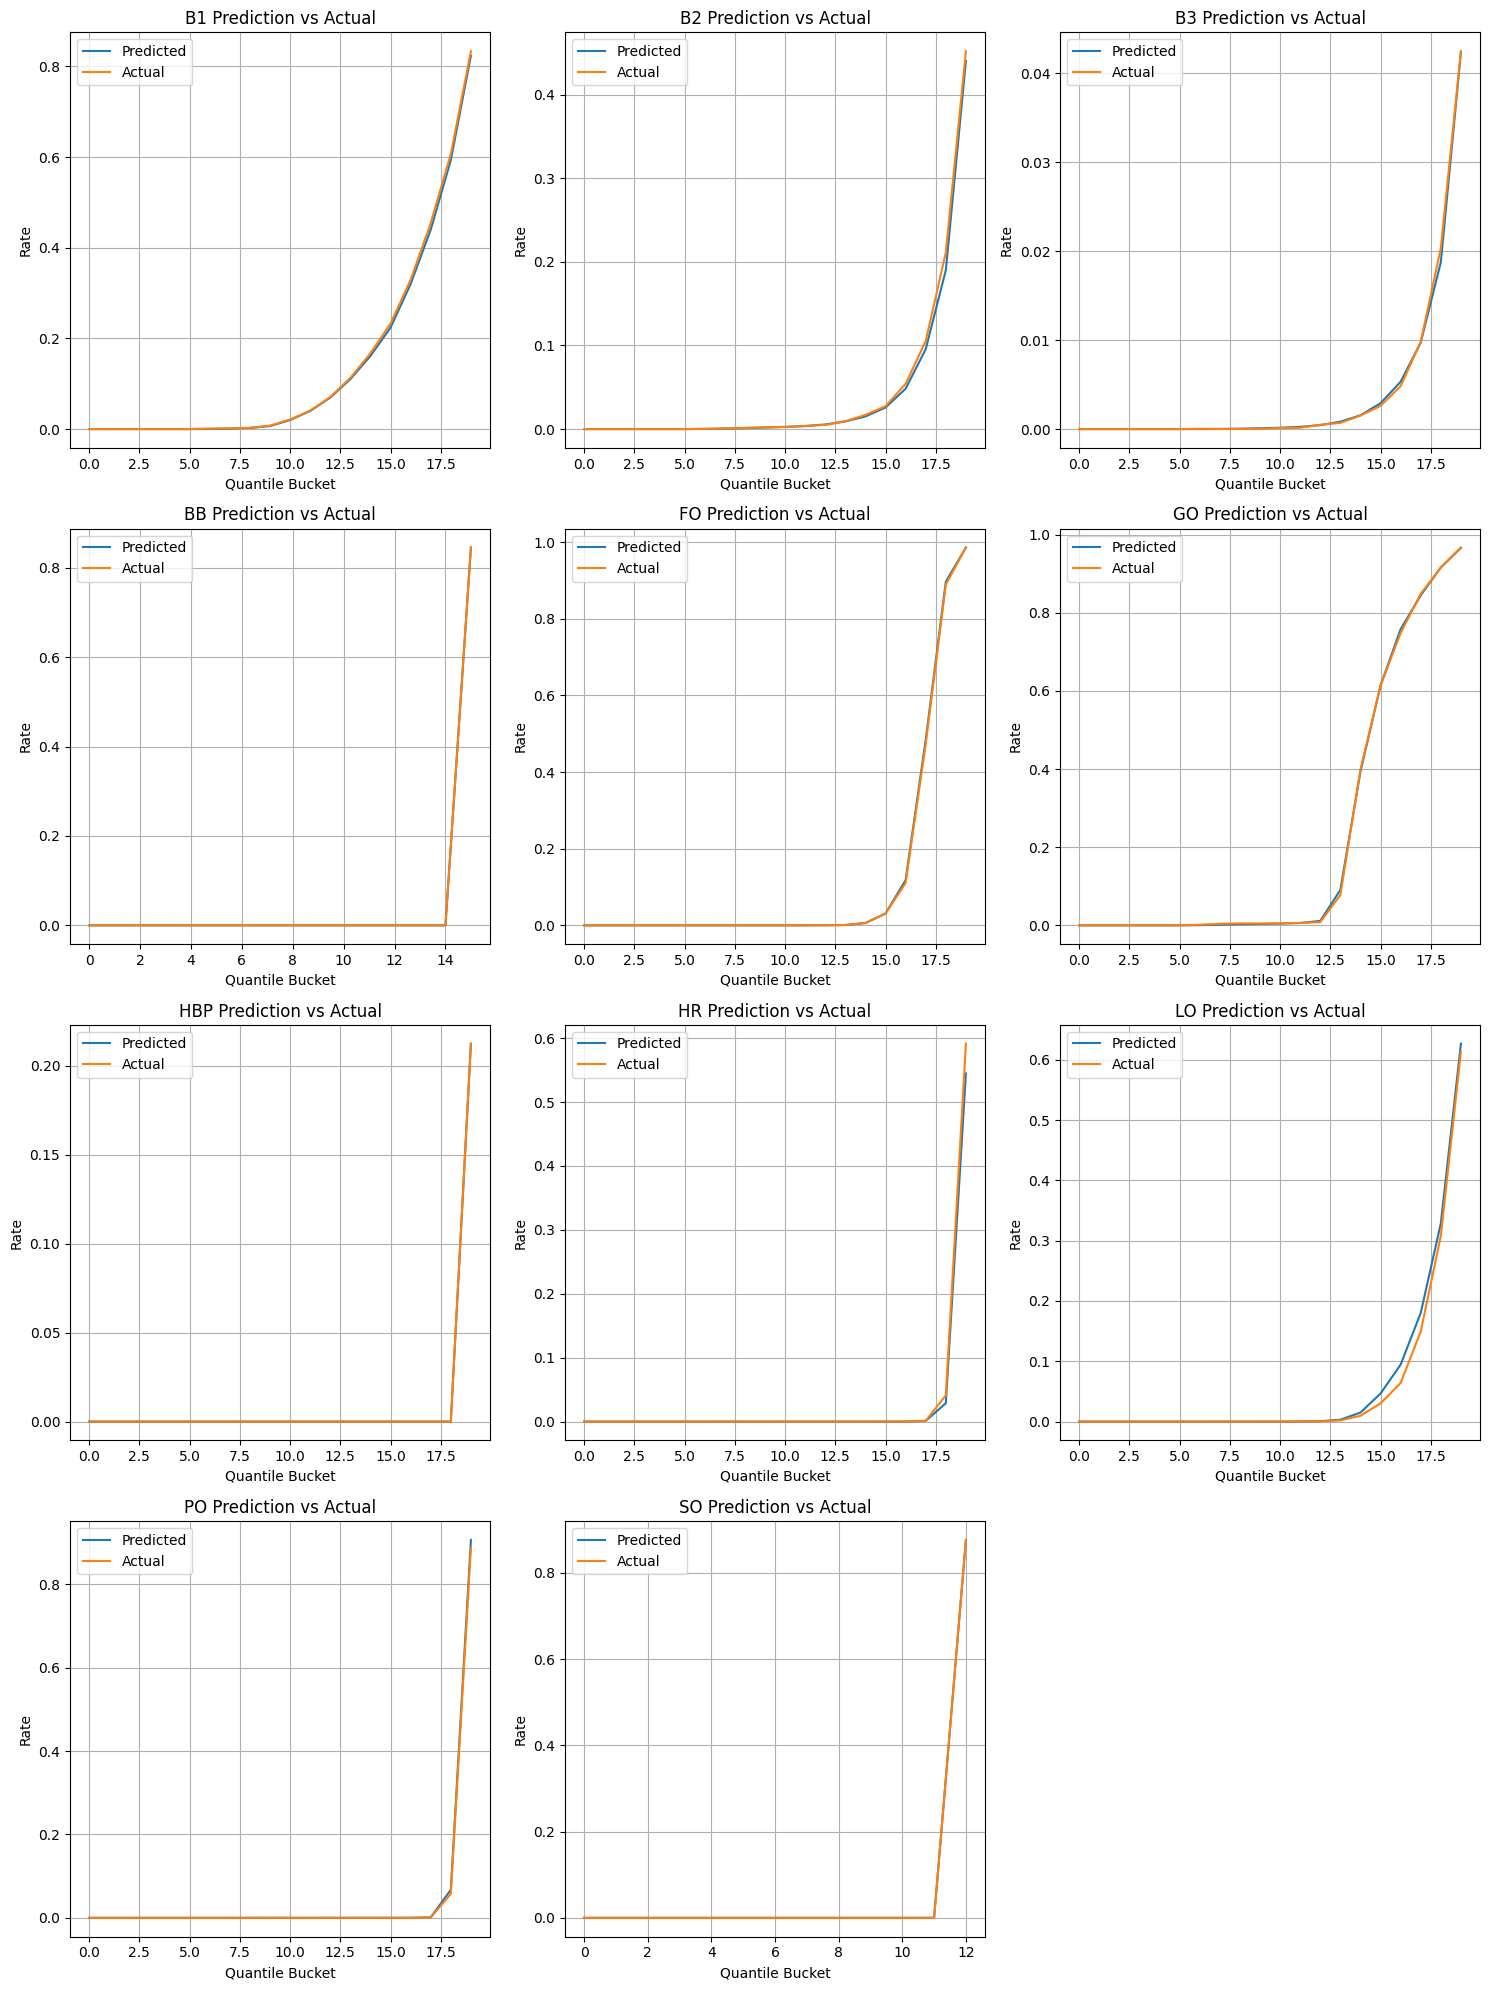

In [30]:
# Adjust the number of rows and columns
n_events = len(events_list)
n_cols = 3
n_rows = (n_events + n_cols - 1) // n_cols  # Ceiling division

# Set square plots: each subplot is 5x5 inches
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, event in enumerate(events_list):
    ax = axes[i]
    pred_col = f"{event}_pred_batted"
    
    if pred_col not in prediction_df.columns:
        continue

    # Bucket the predicted values into quantiles
    prediction_df['bucket'] = pd.qcut(prediction_df[pred_col], q=20, duplicates='drop')

    # Compute averages
    bucket_avg = prediction_df.groupby('bucket').agg(
        avg_pred=(pred_col, 'mean'),
        avg_actual=(event, 'mean')
    ).reset_index()

    # Plot
    ax.plot(bucket_avg['avg_pred'], label='Predicted')
    ax.plot(bucket_avg['avg_actual'], label='Actual')
    ax.set_title(f"{event.upper()} Prediction vs Actual")
    ax.set_xlabel("Quantile Bucket")
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(True)

# Remove extra axes if any
for j in range(n_events, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Calculate PFX

Create lists for containing batted ball predicted outcome rates and PFX

In [31]:
events_list_pred_batted = [f"{event}_pred_batted" for event in events_list]
pfx_list = [f"{event}_pfx" for event in events_list]

Calculate average actual event rates and predicted event rates by game and batSide

In [32]:
game_pfx_df = prediction_df.groupby(['venue_id', 'gamePk', 'batSide', 'date'])[events_list + events_list_pred_batted].mean().reset_index().sort_values(['venue_id', 'date', 'batSide'])

Set rolling window 

In [33]:
num_games = 243

##### Unshifted

Rolling average of last num_games, including the current game <br>
The last values here for each park are the most recent park factors

In [34]:
# Compute the rolling average of the last num_games *including* the current row
rolling_avgs = (
    game_pfx_df
    .groupby(['venue_id', 'batSide'], group_keys=False)
    .apply(lambda group: group[events_list + events_list_pred_batted].shift(0).rolling(num_games, min_periods=1).mean())
)

# Rename columns to indicate they are rolling averages
rolling_avgs.columns = [f'{col}_rolling' for col in events_list + events_list_pred_batted]

# Concatenate with the original dataframe
unshifted_game_pfx_df = pd.concat([game_pfx_df, rolling_avgs], axis=1)

for event in events_list:
    unshifted_game_pfx_df[f'{event}_pfx'] = unshifted_game_pfx_df[f'{event}_rolling'] / unshifted_game_pfx_df[f'{event}_pred_batted_rolling']

Write to CSV

In [35]:
unshifted_game_pfx_df[['venue_id', 'batSide'] + [col for col in unshifted_game_pfx_df if col.endswith("pfx")]].drop_duplicates(subset=['venue_id', 'batSide'], keep='last').to_csv(os.path.join(baseball_path, "Park Latest.csv"), index=False)

##### Shifted

Rolling average of last num_games, excluding the current game <br>
These are the park factors coming into the games

In [36]:
# Compute the rolling average of the last num_games *excluding* the current row
rolling_avgs = (
    game_pfx_df
    .groupby(['venue_id', 'batSide'], group_keys=False)
    .apply(lambda group: group[events_list + events_list_pred_batted].shift(1).rolling(num_games, min_periods=1).mean())
)

# Rename columns to indicate they are rolling averages
rolling_avgs.columns = [f'{col}_rolling' for col in events_list + events_list_pred_batted]

# Concatenate with the original dataframe
shifted_game_pfx_df = pd.concat([game_pfx_df, rolling_avgs], axis=1)

for event in events_list:
    shifted_game_pfx_df[f'{event}_pfx'] = shifted_game_pfx_df[f'{event}_rolling'] / shifted_game_pfx_df[f'{event}_pred_batted_rolling']

### Model B. Weather Factors

$ \hat{\text{eventsModel2}} = \hat{\text{eventsModel}} + pfx + meteo\_x\_vect + meteo\_y\_vect + temperature\_2m + relative\_humidity\_2m + dew\_point\_2m + surface\_pressure + venue\_id + b\_L$

The purpose of this model is to estimate rates of events in games based on weather and venue. This model is trained with expected rates based on the actual batted ball data. This allows for us to control for differences in inherent batted ball data across games. The model then predicts with league average rates to determine how a game with typical batted ball data would differ in various weather and venue conditions. <br>
Ideally, we would then compare these predicted rates to league average rates to determine park x weather factors, multipliers that estimate how much more or less likely given events are on the game-level than under average conditions. <br>
However, this is hard. <br>
Instead, predicted rates are used to assign park-specific quantiles to games based on weather conditions. For instance, a weather conditions that predict a 0.05 projected home run rate at Fenway may get a game assigned to the top quantile of games at that park. From this point, multipliers will be calculated by averaging actual home runs rates at similar games and dividing by batted-ball predicted home run rates at those same games. The result can be interpreted as a multiplier that determines how much more or less likely were home runs at games with similar weather conditions compared to their batted ball likelihoods.

##### Inputs

Meteo weather inputs

In [37]:
meteo_weather_list = ['meteo_x_vect', 'meteo_y_vect', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure']

Parks with sufficient samples

In [38]:
venue_dummy_list = [f'venue_{id}' for id in sorted(prediction_df['venue_id'].value_counts()[lambda x: x > 20000].index.tolist())]

Select inputs

In [39]:
wfx_inputs = events_list_pred_batted + pfx_list + meteo_weather_list + venue_dummy_list + ['b_L']

##### Sample

Merge in park factors

In [40]:
sample_df2 = prediction_df.merge(shifted_game_pfx_df[['gamePk', 'batSide'] + pfx_list], on=['gamePk', 'batSide'], how='left')

Create venue dummies

Note: not all venue dummies may be included in venue_dummy_list

In [41]:
sample_df2['venue_id2'] = sample_df2['venue_id'].copy()

In [42]:
sample_df2 = pd.get_dummies(sample_df2, columns=['venue_id2'], prefix='venue', drop_first=False)

Set pfx to 1 if not in venue sample

Note: we may want to set this in shifted_game_pfx_df and default to a rolling value

In [43]:
sample_df2['sample_venue'] = sample_df2[venue_dummy_list].sum(axis=1)

In [44]:
for pfx in pfx_list:
    sample_df2[pfx] = np.where(sample_df2['sample_venue'] == 0, 1, sample_df2[pfx])

Drop if missing inputs

In [45]:
sample_df2.dropna(subset=wfx_inputs, inplace=True)

Group by game

In [46]:
sample_df2 = sample_df2.groupby(['gamePk', 'date', 'venue_id', 'batSide'])[wfx_inputs + events_list].mean().reset_index()

Define lefty batter dummy

In [47]:
sample_df2['b_L'] = (sample_df2['batSide'] == "L").astype(int)

Drop oldest data (insufficient data)

In [48]:
sample_df2 = sample_df2[sample_df2['date'] > 20180101]

Drop recent data (recent Steamer data is not available)

In [49]:
# sample_df2 = sample_df2[sample_df2['date'] < 20250101]

Split features and target

In [50]:
X = sample_df2[wfx_inputs].values
y = sample_df2[events_list].values

##### Scale

In [51]:
if not hasattr(sys.modules['__main__'], '__file__'):
    # Scale
    scale_wfx = StandardScaler()
    # Fit and transform
    X_scaled = scale_wfx.fit_transform(X)
    # Create directory
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)
    # Save
    pickle.dump(scale_wfx, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "scale_wfx.pkl"), 'wb'))
else:
    X_scaled = scale_wfx.transform(X)

##### Train

In [52]:
%%time
if not hasattr(sys.modules['__main__'], '__file__'):
    class VotingEnsemble:
        def __init__(self, models):
            self.models = models

        def predict(self, X):
            predictions = np.array([model.predict(X, verbose=0) for model in self.models])
            return np.mean(predictions, axis=0)

    ensemble_models = []

    # Create folder
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)

    for i in range(ensemble_size):
        model = Sequential([
            Dense(128, input_shape=(X_scaled.shape[1],), activation='relu'),
            Dropout(0.3),
            Dense(256, activation='relu'),
            Dropout(0.3),
            Dense(128, activation='relu'),
            # Dropout(0.3),
            Dense(64, activation='relu'),
            # Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(y.shape[1], activation='softmax')
        ])

        model.compile(optimizer=Adam(learning_rate=0.001),
                      # loss='categorical_crossentropy',
                      loss=keras.losses.KLDivergence(),
                      metrics=[KLDivergence()])

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_scaled, y,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=1
        )

        # Create folder
        model_path_i = os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, f'predict_wfx_{i}.keras')
        model.save(model_path_i)
        ensemble_models.append(model)

    # Wrap ensemble in predict_wfx for compatibility
    predict_wfx = VotingEnsemble(ensemble_models)

Epoch 1/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - kl_divergence: 0.1097 - loss: 0.1098 - val_kl_divergence: 0.0729 - val_loss: 0.0729
Epoch 2/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0785 - loss: 0.0785 - val_kl_divergence: 0.0664 - val_loss: 0.0665
Epoch 3/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0734 - loss: 0.0734 - val_kl_divergence: 0.0632 - val_loss: 0.0632
Epoch 4/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0712 - loss: 0.0712 - val_kl_divergence: 0.0624 - val_loss: 0.0624
Epoch 5/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0700 - loss: 0.0700 - val_kl_divergence: 0.0616 - val_loss: 0.0616
Epoch 6/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0691 - loss: 0.0691 - val_kl_divergence: 0.0606 - val_loss: 0.0607
Epoch 7/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_divergence: 0.0687 - loss: 0.0687 - val_kl_divergence: 0.0601 - val_loss: 0.0602
Epoch 8/100
882/882 ━━━━━━━

##### Averages

Sample-wide event averages. Used to calculate WFX in A06. Weather

In [53]:
average_df = pd.DataFrame(sample_df2[events_list].mean()).T
if save_event_averages == True:
    average_df.to_csv(os.path.join(baseball_path, "Event Averages.csv"), index=False)

##### Sample

Replace game predicted batted ball data with averages

In [54]:
sample_df3 = sample_df2.copy()
for event in events_list:
    sample_df3[f'{event}_pred_batted'] = sample_df3[event].mean()

Split features and target

In [55]:
X2 = sample_df3[wfx_inputs].values
y2 = sample_df3[events_list].values

##### Scale

scale_wfx defined above

In [56]:
X2_scaled = scale_wfx.transform(X2)

##### Predict

Predict using weather inputs (Model #2)

In [57]:
predictions2 = predict_wfx.predict(X2_scaled)
prediction_df2 = pd.DataFrame(predictions2, columns=events_list)

prediction_df2 = prediction_df2.add_suffix('_pred_weather')

prediction_df2 = pd.concat([prediction_df2, sample_df3.reset_index()], axis=1)

Calculate WFX

Predicted, based on weather, over predicted, based on batted-ball data

In [58]:
for event in events_list:
    prediction_df2[f'{event}_wfx_unadj'] = prediction_df2[f'{event}_pred_weather'] / prediction_df2[f'{event}_pred_batted']

Highlight outliers

In [59]:
# Sort and get top/bottom 500
top_500 = prediction_df2.nlargest(500, 'hr_wfx_unadj')
bottom_500 = prediction_df2.nsmallest(500, 'hr_wfx_unadj')

# Get value counts
top_counts = top_500['venue_id'].value_counts().head(5)
bottom_counts = bottom_500['venue_id'].value_counts().head(5)

# Combine into a 5x4 DataFrame
result_df = pd.DataFrame({
    'Top Venue': top_counts.index,
    'Top Count': top_counts.values,
    'Bottom Venue': bottom_counts.index,
    'Bottom Count': bottom_counts.values
})

result_df

,Top Venue,Top Count,Bottom Venue,Bottom Count
0,19,210,7,227
1,17,88,2394,59
2,2602,71,3312,52
3,3313,42,17,46
4,4,26,3,41


Average weather conditions of best and worst home run games

In [60]:
prediction_df2.sort_values('hr_wfx_unadj', ascending=False).head(100)[['meteo_y_vect', 'temperature_2m']].mean()

meteo_y_vect      9.632575
temperature_2m   86.880524
dtype: float64

In [61]:
prediction_df2.sort_values('hr_wfx_unadj', ascending=False).tail(100)[['meteo_y_vect', 'temperature_2m']].mean()

meteo_y_vect     -4.399400
temperature_2m   54.373083
dtype: float64

##### Plot

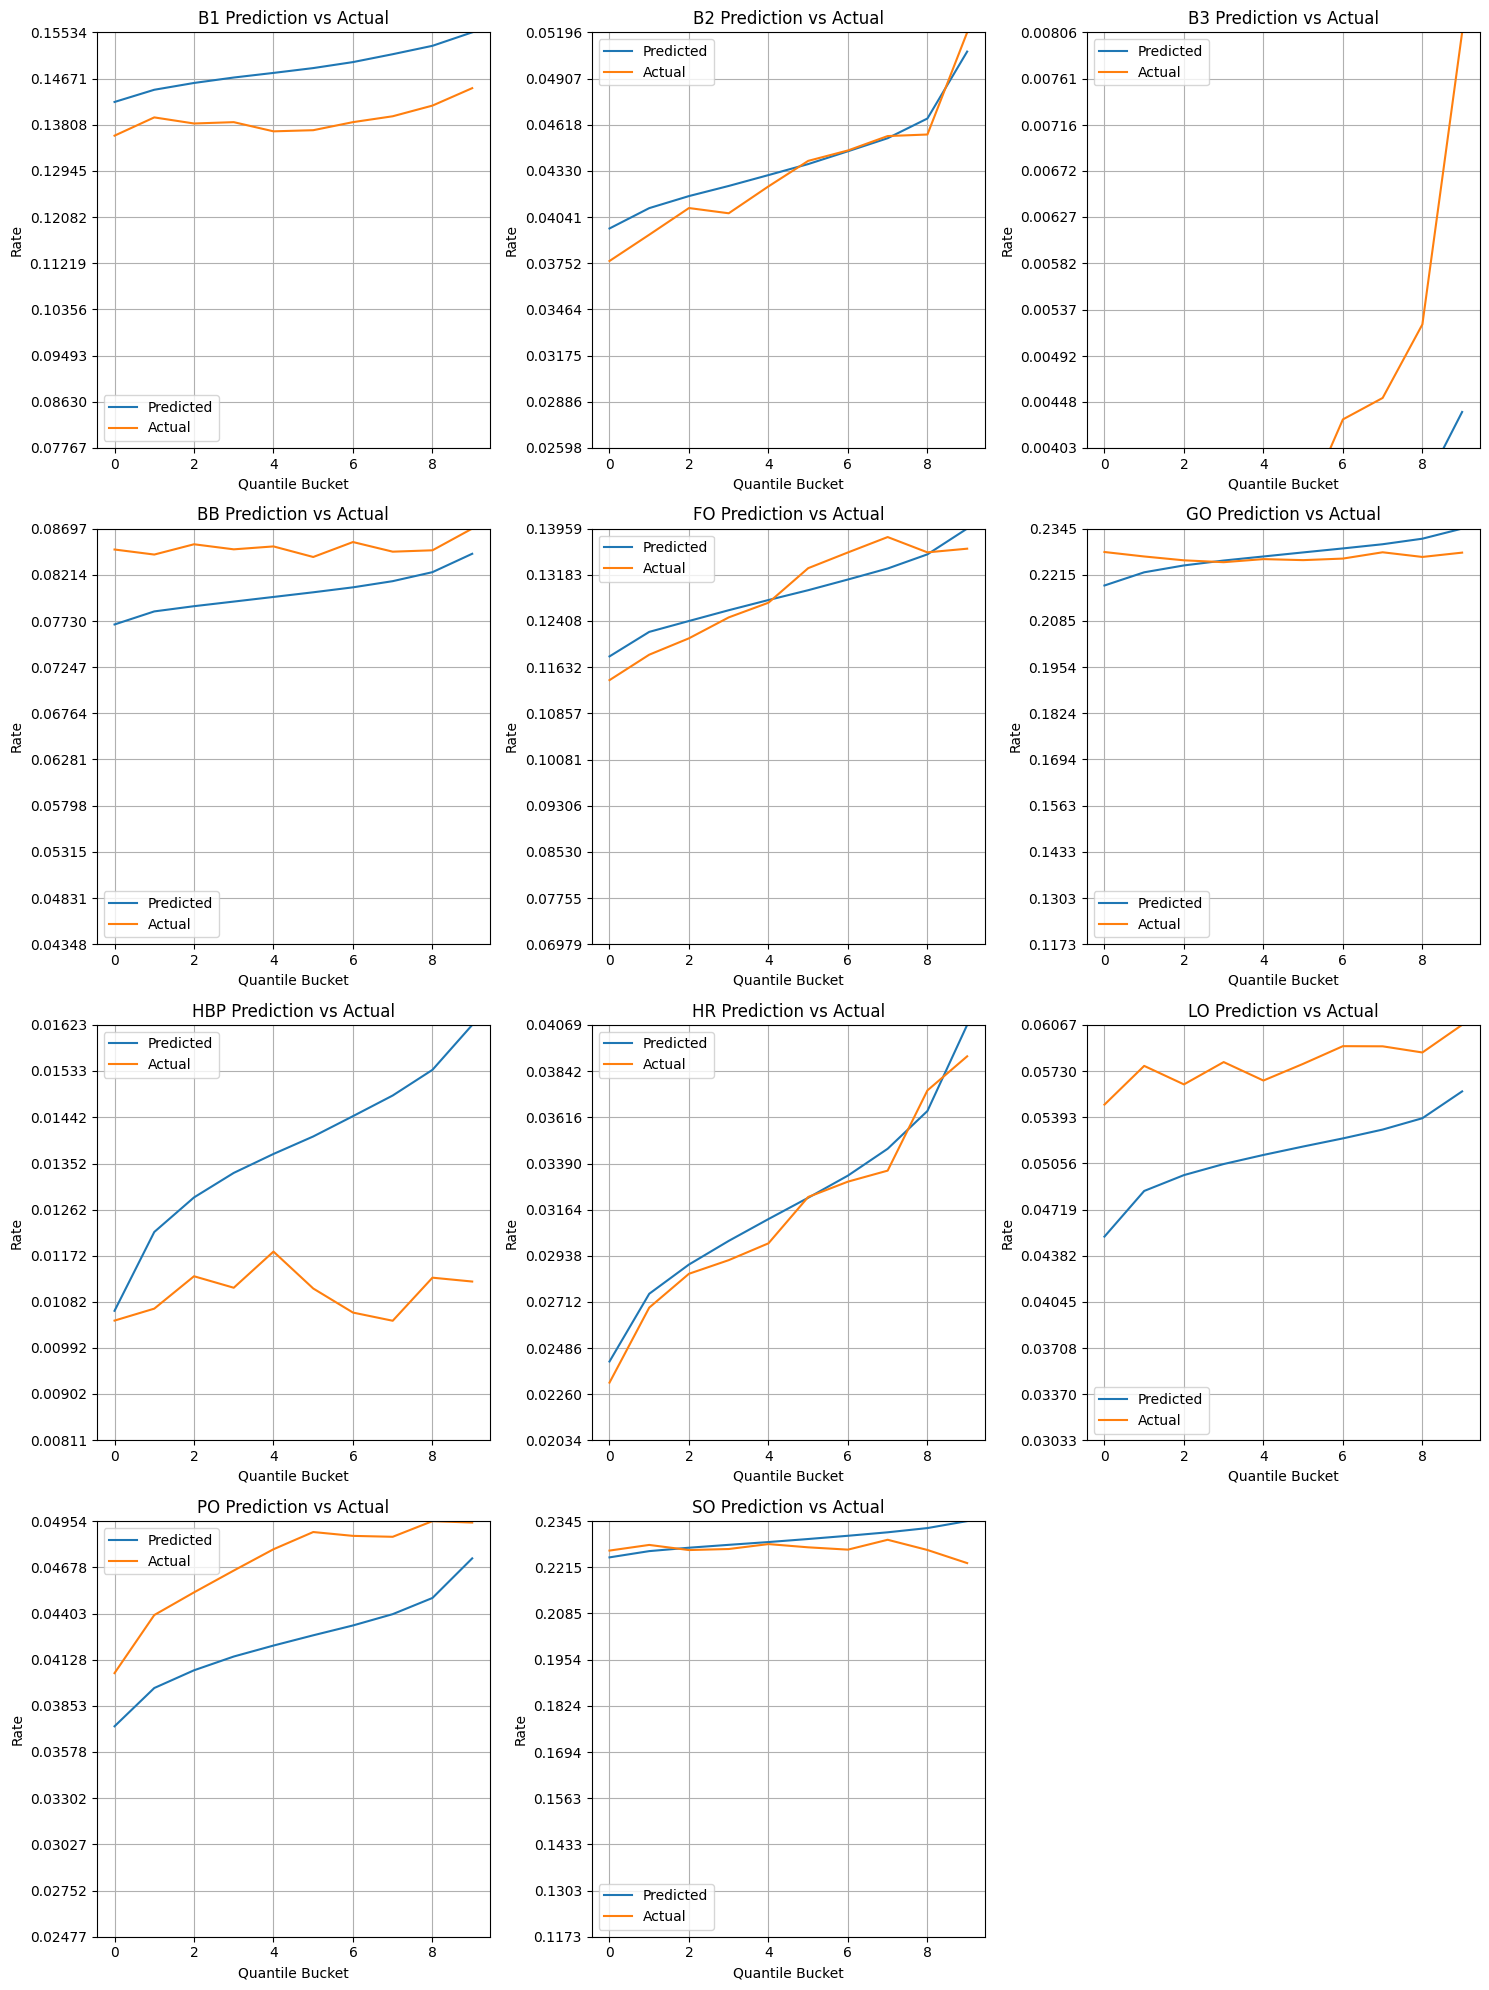

In [62]:
# Adjust the number of rows and columns
n_events = len(events_list)
n_cols = 3
n_rows = (n_events + n_cols - 1) // n_cols  # Ceiling division

# Set square plots: each subplot is 5x5 inches
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, event in enumerate(events_list):
    ax = axes[i]
    pred_col = f"{event}_pred_weather"
    
    if pred_col not in prediction_df2.columns:
        continue

    # Bucket the predicted values into quantiles
    prediction_df2['bucket'] = pd.qcut(prediction_df2[pred_col], q=10, duplicates='drop')

    # Compute averages
    bucket_avg = prediction_df2.groupby('bucket').agg(
        avg_pred=(pred_col, 'mean'),
        avg_actual=(event, 'mean')
    ).reset_index()

    # Plot
    ax.plot(bucket_avg['avg_pred'], label='Predicted')
    ax.plot(bucket_avg['avg_actual'], label='Actual')
    ax.set_title(f"{event.upper()} Prediction vs Actual")
    ax.set_xlabel("Quantile Bucket")
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(True)

    # Set y-axis limits: from 1/3 of the max to the max
    y_max = max(bucket_avg['avg_pred'].max(), bucket_avg['avg_actual'].max())
    y_min = y_max / 2

    # Create 10 evenly spaced ticks from y_min to y_max
    ticks = np.linspace(y_min, y_max, 10)
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(np.round(ticks, 5))  # round for cleaner labels

# Remove extra axes if any
for j in range(n_events, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Drop bucket column 

In [63]:
prediction_df2.drop(columns={'bucket'}, inplace=True)

##### Calibrate

In [64]:
%%time
n = 50  # number of last past games to consider 

# Convert pandas DataFrame to Polars DataFrame
df = pl.from_pandas(prediction_df2.copy())

# Initialize lists to store results for new columns
results_mean = {f'{event}_mean': [] for event in events_list}
results_pred_batted_mean = {f'{event}_pred_batted_mean': [] for event in events_list}

# Iterate through each row of the Polars DataFrame
for i in range(len(df)):
    current_row = df.row(i, named=True)  # Get the current row data as a dictionary
    past_data = df.slice(0, i) # Get all data from previous rows in the DataFrame (already chronological)

    # Process for each event type
    for event in events_list:
        true_col = event            # Column for '{event}_mean' (your actual event result)
        model_col = f'{event}_pred_batted' # Column for '{event}_pred_mean' (your model's event prediction)

        # --- Step 1: Attempt strict filtering (venue_id AND batSide) ---
        past_subset_strict_filter = past_data.filter(
            (pl.col('venue_id') == current_row['venue_id']) &
            (pl.col('batSide') == current_row['batSide'])
        )

        games_to_average = None # Initialize variable to hold the final set of games

        # --- Step 2: Check count and apply conditional logic ---
        if len(past_subset_strict_filter) < n:
            # If strict filter yields less than 'n' games, fallback to broader filter
            # print(f"Row {i}, Event {event}: Less than {n} games with strict filter ({len(past_subset_strict_filter)} found). Falling back to batSide only.")
            past_subset_broad_filter = past_data.filter(
                pl.col('batSide') == current_row['batSide']
            )
            games_to_average = past_subset_broad_filter
        else:
            # If strict filter yields 'n' or more games, use those
            games_to_average = past_subset_strict_filter

        # --- Handle cases where even the broadest filter yields no games ---
        if games_to_average.is_empty():
            results_mean[f'{event}_mean'].append(np.nan)
            results_pred_batted_mean[f'{event}_pred_batted_mean'].append(np.nan)
            continue

        # --- Step 3: Take the last 'n' games from the chosen subset and average ---
        final_games_for_avg = games_to_average.tail(n)

        # Compute the mean of the relevant columns
        results_mean[f'{event}_mean'].append(final_games_for_avg[true_col].mean())
        results_pred_batted_mean[f'{event}_pred_batted_mean'].append(final_games_for_avg[model_col].mean())

# Combine all collected results into a single dictionary
final_results_combined = {}
final_results_combined.update(results_mean)
final_results_combined.update(results_pred_batted_mean)

# Add the newly computed columns to the Polars DataFrame
for col_name, values_list in final_results_combined.items():
    df = df.with_columns(pl.Series(name=col_name, values=values_list))

# Convert the final Polars DataFrame back to a pandas DataFrame
prediction_df2 = df.to_pandas()

CPU times: total: 1h 52min 8s
Wall time: 11min 56s


In [65]:
prediction_df2.tail()

,b1_pred_weather,b2_pred_weather,b3_pred_weather,bb_pred_weather,fo_pred_weather,go_pred_weather,hbp_pred_weather,hr_pred_weather,lo_pred_weather,po_pred_weather,so_pred_weather,index,gamePk,date,venue_id,batSide,b1_pred_batted,b2_pred_batted,b3_pred_batted,bb_pred_batted,fo_pred_batted,go_pred_batted,hbp_pred_batted,hr_pred_batted,lo_pred_batted,po_pred_batted,so_pred_batted,b1_pfx,b2_pfx,b3_pfx,bb_pfx,fo_pfx,go_pfx,hbp_pfx,hr_pfx,lo_pfx,po_pfx,so_pfx,meteo_x_vect,meteo_y_vect,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,venue_1,venue_2,venue_3,venue_4,venue_5,venue_7,venue_10,venue_12,venue_13,venue_14,venue_15,venue_17,venue_19,venue_22,venue_31,venue_32,venue_680,venue_2392,venue_2394,venue_2395,venue_2602,venue_2680,venue_2681,venue_2889,venue_3289,venue_3309,venue_3312,venue_3313,venue_4169,venue_4705,venue_5325,b_L,b1,b2,b3,bb,fo,go,hbp,hr,lo,po,so,b1_wfx_unadj,b2_wfx_unadj,b3_wfx_unadj,bb_wfx_unadj,fo_wfx_unadj,go_wfx_unadj,hbp_wfx_unadj,hr_wfx_unadj,lo_wfx_unadj,po_wfx_unadj,so_wfx_unadj,b1_mean,b2_mean,b3_mean,bb_mean,fo_mean,go_mean,hbp_mean,hr_mean,lo_mean,po_mean,so_mean,b1_pred_batted_mean,b2_pred_batted_mean,b3_pred_batted_mean,bb_pred_batted_mean,fo_pred_batted_mean,go_pred_batted_mean,hbp_pred_batted_mean,hr_pred_batted_mean,lo_pred_batted_mean,po_pred_batted_mean,so_pred_batted_mean
35239,0.148178,0.046223,0.003156,0.078753,0.140103,0.220017,0.011944,0.027846,0.052037,0.042913,0.228830,48943,778562,20250327,4169,R,0.139101,0.043243,0.003969,0.085004,0.128403,0.226474,0.010999,0.031313,0.057875,0.046930,0.226687,1.020591,1.078491,0.916154,1.000000,1.045877,1.021943,1.000000,0.879009,0.823089,0.955835,1.000000,11.323444,-5.772936,78.576800,49.402695,58.056800,1021.683170,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0,0.090909,0.045455,0.022727,0.136364,0.022727,0.204545,0.068182,0.022727,0.068182,0.090909,0.227273,1.065259,1.068905,0.795057,0.926459,1.091117,0.971488,1.085896,0.889267,0.899116,0.914404,1.009455,0.141828,0.047172,0.003822,0.067494,0.132433,0.255816,0.007964,0.019182,0.067646,0.042803,0.213838,0.139101,0.043243,0.003969,0.085004,0.128403,0.226474,0.010999,0.031313,0.057875,0.046930,0.226687
35240,0.149053,0.044089,0.003157,0.078303,0.127966,0.227510,0.014967,0.032105,0.051281,0.043201,0.228368,48944,778563,20250318,2397,L,0.139101,0.043243,0.003969,0.085004,0.128403,0.226474,0.010999,0.031313,0.057875,0.046930,0.226687,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,70.000000,60.000000,57.000000,1011.538300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.096774,0.064516,0.000000,0.096774,0.096774,0.290323,0.000000,0.000000,0.096774,0.032258,0.225806,1.071546,1.019555,0.795307,0.921169,0.996595,1.004574,1.360771,1.025267,0.886062,0.920548,1.007414,0.132681,0.037814,0.003417,0.098905,0.131574,0.218923,0.006833,0.031426,0.053233,0.044864,0.240331,0.139101,0.043243,0.003969,0.085004,0.128403,0.226474,0.010999,0.031313,0.057875,0.046930,0.226687
35241,0.148989,0.043106,0.003008,0.079399,0.128123,0.228857,0.014761,0.032352,0.051721,0.043517,0.226167,48945,778563,20250318,2397,R,0.139101,0.043243,0.003969,0.085004,0.128403,0.226474,0.010999,0.031313,0.057875,0.046930,0.226687,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,70.000000,60.000000,57.000000,1011.538300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000

##### Calculate WFX

WFX = Actual for similar games / Predicted (using batted-ball data) in similar games 

In [66]:
for event in events_list:
    prediction_df2[f'{event}_wfx_adj'] = prediction_df2[f'{event}_mean'] / prediction_df2[f'{event}_pred_batted_mean']

##### Evaluate

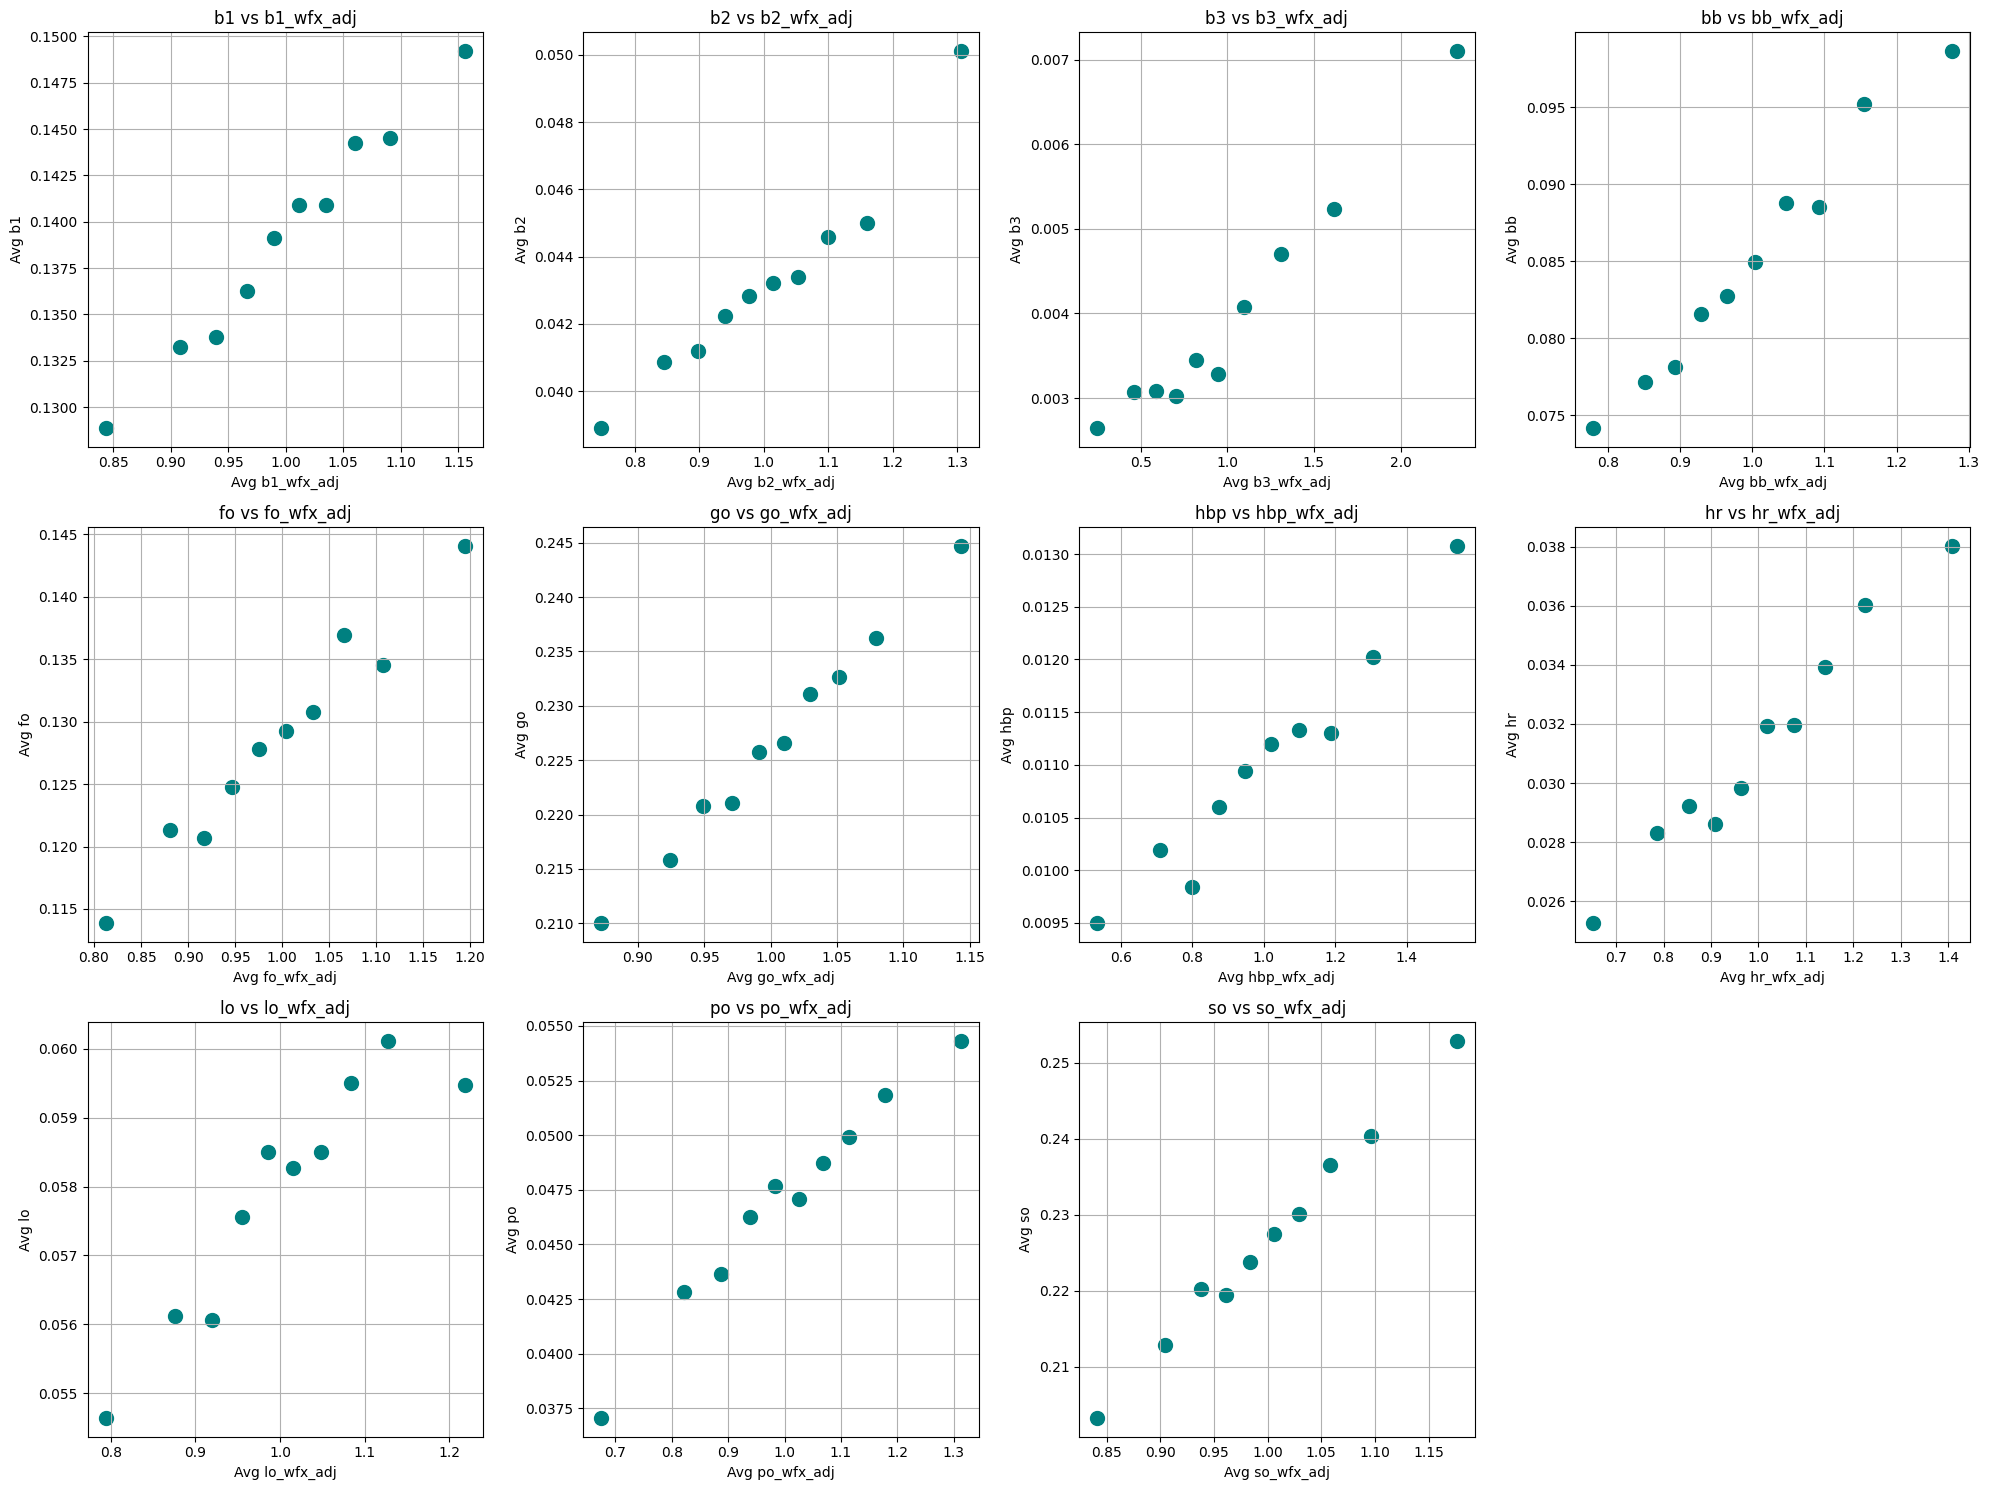

In [67]:
n_quantiles = 10

# Determine grid size for subplots
n_events = len(events_list)
n_cols = math.ceil(n_events**0.5)
n_rows = math.ceil(n_events / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))  # make each subplot square-ish
axes = axes.flatten()

for i, event in enumerate(events_list):
    bucket_col = f'{event}_bucket'
    
    # Create quantile bins for this event
    prediction_df2[bucket_col] = pd.qcut(prediction_df2[f'{event}_wfx_adj'], q=n_quantiles, labels=False)
    
    # Aggregate per bucket
    bucket_avg = prediction_df2.groupby(bucket_col).agg({
        f'{event}_wfx_adj': 'mean',
        event: 'mean'
    }).reset_index()
    
    # Scatter plot
    axes[i].scatter(bucket_avg[f'{event}_wfx_adj'], bucket_avg[event], s=100, color='teal')
    axes[i].set_xlabel(f'Avg {event}_wfx_adj')
    axes[i].set_ylabel(f'Avg {event}')
    axes[i].set_title(f'{event} vs {event}_wfx_adj')
    axes[i].grid(True)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


##### WFX Dataframe

Convert from long to wide

In [68]:
l_shifted_game_wfx_df = prediction_df2[prediction_df2['batSide'] == "L"]
r_shifted_game_wfx_df = prediction_df2[prediction_df2['batSide'] == "R"]

wfx_df = pd.merge(l_shifted_game_wfx_df, r_shifted_game_wfx_df, on=['venue_id', 'gamePk', 'date'], how='left', suffixes=("_l", "_r"))

Write all game WFX to CSV

In [69]:
wfx_df[['venue_id', 'gamePk', 'date'] + [col for col in wfx_df if "wfx" in col] + [col for col in wfx_df if "pred" in col] + [f'{event}_l' for event in events_list] + [f'{event}_r' for event in events_list]].to_csv(
    os.path.join(baseball_path, "Park and Weather Factors.csv"), index=False)

Write individual-game WFX to CSV

In [70]:
for date in wfx_df['date'].unique():
    wfx_df[wfx_df['date'] == date][['venue_id', 'gamePk', 'date'] + [col for col in wfx_df if "wfx" in col]].to_csv(
        os.path.join(baseball_path, "B02. WFX", f"Park and Weather Factors {date}.csv"), index=False)

##### Player Stat DataFrame

This comes from Model #1 and is completely independent of Model #2. Placement is for convenience, not necessarily logic.

Replace actual event rates with predicted ones

In [71]:
prediction_df[events_list] = prediction_df[events_list_pred_batted].copy()

Drop unneeded columns

In [72]:
if 'bucket' in list(prediction_df.columns):
    prediction_df.drop(columns=['bucket'], inplace=True)

Calculate rolling stats

In [73]:
short, long = 50, 300

Short

In [74]:
start_time = time.time()
df_short = rolling_pas(prediction_df, short, events_list)
print(f"Short took {time.time() - start_time:.2f} seconds")

Short took 7.25 seconds


Long

In [75]:
start_time = time.time()
df_long = rolling_pas(prediction_df, long, events_list)
df_long = df_long.add_suffix("_long")
print(f"Long took {time.time() - start_time:.2f} seconds")

# We only need the rolling stats from long (the rest are in df_short)
long_stats = batter_stats_long + pitcher_stats_long
df_long = df_long[long_stats]

Long took 8.75 seconds


Merge long stats onto rolling (and other) stats

In [76]:
final_dataset = pd.concat([df_short, df_long], axis=1)
final_dataset.reset_index(drop=True, inplace=True)
final_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)
final_dataset.drop(columns=events_list + ['Cut'], inplace=True)

Add event dummies

In [77]:
event_dummies = pd.get_dummies(final_dataset['eventsModel']).astype(int)

In [78]:
final_dataset = pd.concat([final_dataset, event_dummies], axis=1)

Clean

In [79]:
final_dataset = final_dataset.replace([float('inf'), float('-inf')], 0)

Write to CSV

In [80]:
%%time
final_dataset.to_csv(os.path.join(baseball_path, "PA Dataset.csv"), index=False)

CPU times: total: 2min 6s
Wall time: 2min 7s


In [81]:
print(f"Data as of {final_dataset['date'].max()}.")

Data as of 20250928.


### Required Follow-Ups:
- Model A. Batted Ball
    - Model B. Park and Weather Factors
    - B01. Matchups
    - M02. Stat Imputations
    - M03. Plate Appearances
- Model B. Park and Weather Factors
    - M03. Plate Appearances

Note: You should avoid rerunning Model A. Batted Ball as much as possible. It's slow. Likely shouldn't need many updates anyway. 